# Experiment 2 — VAE Sample-Size Saturation Study

**Question:** for each QUIDA dataset, how many samples can one trained VAE generate before extra samples
stop adding value (fidelity plateaus and the generator begins repeating itself)?

**Method (no self-consuming loop).** For each dataset and each random seed: train the VAE **once** on the
real training split, then **generate at increasing sizes** (1x, 2x, 3x, 5x, 8x the real count) from that
single fixed model. Every generated set is scored against the same real reference. Results are **averaged
over seeds** so the recommended size is a stable knee, not an artifact of one split.

**Metrics:** MMD, Wasserstein, Correlation Difference, OCSVM coverage gap + Score Gap, Variance Increase,
and Density/Coverage (precision-recall for generative models). Distribution/geometry metrics are computed
in a shared standardized-PCA embedding of the real data; per-channel metrics (Wasserstein, correlation)
in standardized original space.

**Output:** per-dataset metric-vs-size tables and curves (knee marked), PCA overlays across sizes, and a
recommended sample size per dataset, plus a cross-dataset summary.

> Note: a fixed VAE does not lose per-sample quality as you draw more; what saturates is the *marginal
> value* of each extra sample. So the deliverable is a **saturation point**, not a cliff.

## 1. Import libraries

In [1]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

_saving = getattr(keras, "saving", None)
def _pick(fn): return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object   = _pick("serialize_keras_object")
deserialize_keras_object = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__,
      "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")


2026-08-24 20:28:10.420086: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787603290.631814     189 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787603290.691808     189 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787603291.222325     189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787603291.222362     189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787603291.222365     189 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.1 | Keras: 3.10.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [ ]:
@dataclass
class Config:
    # Dataset provided by the professor in Vocareum
    data_dir: Path = field(
        default_factory=lambda: (Path.cwd() / "../Preprocessed_dataset").resolve()
    )

    # Generated results stay inside the current EXP_2 directory
    output_dir: Path = field(
        default_factory=lambda: Path.cwd() / "vae_size_study"
    )

    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = None

    seed: int = 42
    val_split: float = 0.2

    # --- sample-size sweep ---
    multipliers: tuple = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
    n_seeds: int = 3
    recommend_tol: float = 0.05

    # --- preprocessing (reversible) ---
    use_signed_log: bool = True
    drop_constant: bool = True
    const_eps: float = 1e-8
    use_pca: bool = True
    pca_components: int = 32

    # --- model ---
    latent_dim: int = 16
    beta: float = 1.0
    free_bits: float = 0.5
    kl_anneal_epochs: int = 30
    base_filters: int = 64

    # --- training ---
    epochs: int = 250
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 30

    sample_from_posterior: bool = True

    # --- evaluation ---
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150
    mmd_cap: int = 800
    pca_plot: bool = True
    kl_collapse_thresh: float = 1e-2


CFG = Config()

CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Data:", CFG.data_dir)
print("Output:", CFG.output_dir)
print(
    "Multipliers:", CFG.multipliers,
    "| seeds:", CFG.n_seeds
)

Data: /voc/data/data_zain/Dataset
Output: /voc/work/exp_2/vae_size_study
Multipliers: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10) | seeds: 3


In [3]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed)
    try: keras.utils.set_random_seed(seed)
    except Exception: tf.random.set_seed(seed)
set_seeds(CFG.seed)


## 3. Load the four datasets

In [4]:
def _clean_name(fn):
    s = Path(fn).stem; return s[:-4] if s.endswith("_raw") else s

def discover_datasets(cfg):
    if cfg.datasets:
        items = list(cfg.datasets.items())
        miss = [str(cfg.data_dir/f) for _,f in items if not (cfg.data_dir/f).exists()]
        if miss: raise FileNotFoundError("Missing: " + ", ".join(miss))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q:(q.name.count("_"), q.name))
        if not files: raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data={}
    for name,fname in items:
        data[name]=np.load(cfg.data_dir/fname, allow_pickle=False).astype(np.float32)
        print(f"  {name:16s} <- {fname:26s} {data[name].shape}")
    return data
RAW = discover_datasets(CFG)


  X_imu            <- X_imu_raw.npy              (99, 32, 3)
  X_imu_ir         <- X_imu_ir_raw.npy           (99, 32, 771)
  X_imu_radar      <- X_imu_radar_raw.npy        (99, 32, 1137)
  X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     (99, 32, 1905)


## 4. Data validation

In [5]:
def validate_dataset(name, X, cfg):
    assert X.ndim==3, f"{name}: need (N,T,F), got {X.shape}"
    N,T,F=X.shape
    n_nan,n_inf=int(np.isnan(X).sum()),int(np.isinf(X).sum())
    if n_nan or n_inf:
        X=np.where(np.isfinite(X),X,np.nan)
        fm=np.nan_to_num(np.nanmean(X.reshape(-1,F),axis=0)); ii=np.where(~np.isfinite(X)); X[ii]=np.take(fm,ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst=int((np.ptp(X.reshape(-1,F).astype(np.float64),axis=0)<=cfg.const_eps).sum())
    print(f"  {name:16s} N={N} T={T} F={F} const_cols={nconst} min={X.min():+.1f} max={X.max():+.1f}")
    return X.astype(np.float32)
RAW={n:validate_dataset(n,X,CFG) for n,X in RAW.items()}


  X_imu            N=99 T=32 F=3 const_cols=0 min=-73.4 max=+72.1
  X_imu_ir         N=99 T=32 F=771 const_cols=0 min=-73.4 max=+72.1
  X_imu_radar      N=99 T=32 F=1137 const_cols=294 min=-73.4 max=+1523.0
  X_imu_ir_radar   N=99 T=32 F=1905 const_cols=294 min=-73.4 max=+1523.0


## 5. Reversible preprocessing (`Prep`)

In [6]:
def _slog(x): return np.sign(x)*np.log1p(np.abs(x))
def _islog(y): return np.sign(y)*np.expm1(np.abs(y))

class Prep:
    def __init__(self,cfg): self.cfg=cfg
    def fit(self,X):
        N,T,F=X.shape; self.T,self.F_full=T,F
        o=X.reshape(-1,F).astype(np.float64)
        self.keep=(np.ptp(o,axis=0)>self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F,bool)
        lg=_slog(o) if self.cfg.use_signed_log else o
        self.const=lg.mean(0); kept=lg[:,self.keep]
        if self.cfg.use_pca and kept.shape[1]>self.cfg.pca_components:
            k=min(self.cfg.pca_components,kept.shape[1],len(kept)-1)
            self.pca=PCA(k,random_state=self.cfg.seed).fit(kept); comps=self.pca.transform(kept)
        else: self.pca=None; comps=kept
        self.scaler=MinMaxScaler().fit(comps); self.K=comps.shape[1]; self.n_dropped=int((~self.keep).sum())
        return self
    def transform(self,X):
        n=len(X); lg=X.reshape(-1,self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: lg=_slog(lg)
        kept=lg[:,self.keep]; comps=self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n,self.T,self.K).astype("float32")
    def inverse(self,Xs):
        n=len(Xs); comps=self.scaler.inverse_transform(Xs.reshape(-1,self.K))
        kept=self.pca.inverse_transform(comps) if self.pca is not None else comps
        full=np.zeros((len(kept),self.F_full)); full[:,self.keep]=kept
        if self.n_dropped: full[:,~self.keep]=self.const[~self.keep]
        if self.cfg.use_signed_log: full=_islog(full)
        return full.reshape(n,self.T,self.F_full).astype("float32")

def split_data(X,cfg,seed):
    return train_test_split(X,test_size=cfg.val_split,random_state=seed,shuffle=True)


## 6. Build the Beta-VAE (free-bits + annealable beta)

In [7]:
@register_keras_serializable()
class Sampling(layers.Layer):
    def call(self,inp):
        zm,zlv=inp; return zm+tf.exp(0.5*zlv)*tf.random.normal(tf.shape(zm))

def build_encoder(T,F,ld,base):
    xi=keras.Input((T,F))
    x=layers.Conv1D(base,3,padding="same",activation="relu")(xi)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    x=layers.Conv1D(base//2,3,padding="same",activation="relu")(x)
    x=layers.Flatten()(x); x=layers.Dense(base,activation="relu")(x)
    zm=layers.Dense(ld,name="z_mean")(x); zlv=layers.Dense(ld,name="z_log_var")(x)
    return keras.Model(xi,[zm,zlv,Sampling()([zm,zlv])],name="encoder")

def build_decoder(T,F,ld,base):
    zi=keras.Input((ld,))
    x=layers.Dense(base,activation="relu")(zi); x=layers.Dense(T*(base//2),activation="relu")(x)
    x=layers.Reshape((T,base//2))(x)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    return keras.Model(zi,layers.Conv1D(F,3,padding="same",activation="sigmoid")(x),name="decoder")

@register_keras_serializable()
class BetaVAE(keras.Model):
    def __init__(self,encoder,decoder,beta=1.0,free_bits=0.0,**kw):
        super().__init__(**kw); self.encoder,self.decoder=encoder,decoder
        self.beta_target=float(beta); self.free_bits=float(free_bits)
        self.beta_var=tf.Variable(float(beta),trainable=False,dtype=tf.float32,name="beta")
        self.total_tracker=keras.metrics.Mean(name="total_loss")
        self.rec_tracker=keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker=keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self): return [self.total_tracker,self.rec_tracker,self.kl_tracker]
    def compute_losses(self,x):
        zm,zlv,z=self.encoder(x); recon=self.decoder(z)
        rec=tf.reduce_mean(tf.reduce_sum(tf.square(x-recon),axis=[1,2]))
        kld=-0.5*(1+zlv-tf.square(zm)-tf.exp(zlv)); kldm=tf.reduce_mean(kld,axis=0)
        kl_raw=tf.reduce_sum(kldm); kl_fb=tf.reduce_sum(tf.maximum(kldm,self.free_bits))
        return rec,kl_raw,rec+self.beta_var*kl_fb
    def train_step(self,data):
        x=data[0] if isinstance(data,(tuple,list)) else data
        with tf.GradientTape() as tape: rec,kl,tot=self.compute_losses(x)
        self.optimizer.apply_gradients(zip(tape.gradient(tot,self.trainable_weights),self.trainable_weights))
        self.total_tracker.update_state(tot); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {"loss":self.total_tracker.result(),"reconstruction_loss":self.rec_tracker.result(),"kl_loss":self.kl_tracker.result()}
    def call(self,x,training=None):
        _,_,z=self.encoder(x); return self.decoder(z)
    def get_config(self):
        return {"encoder":serialize_keras_object(self.encoder),"decoder":serialize_keras_object(self.decoder),
                "beta":self.beta_target,"free_bits":self.free_bits}
    @classmethod
    def from_config(cls,c):
        return cls(deserialize_keras_object(c["encoder"]),deserialize_keras_object(c["decoder"]),
                   beta=c["beta"],free_bits=c.get("free_bits",0.0))

def build_vae(T,F,cfg):
    v=BetaVAE(build_encoder(T,F,cfg.latent_dim,cfg.base_filters),
              build_decoder(T,F,cfg.latent_dim,cfg.base_filters),beta=cfg.beta,free_bits=cfg.free_bits)
    v.compile(optimizer=keras.optimizers.Adam(cfg.learning_rate)); return v


## 7. Train the VAE (once per seed)

In [8]:
class KLAnneal(keras.callbacks.Callback):
    def __init__(self,bv,t,n): super().__init__(); self.bv,self.t,self.n=bv,float(t),max(1,int(n))
    def on_epoch_begin(self,epoch,logs=None): self.bv.assign(self.t*min(1.0,(epoch+1)/self.n))

class ValLoss(keras.callbacks.Callback):
    def __init__(self,Xv,fb): super().__init__(); self.Xv=Xv.astype("float32"); self.fb=float(fb)
    def on_epoch_end(self,epoch,logs=None):
        if logs is None: return
        zm,zlv,z=self.model.encoder(self.Xv,training=False); recon=self.model.decoder(z,training=False)
        vrec=float(tf.reduce_mean(tf.reduce_sum(tf.square(self.Xv-recon),axis=[1,2])))
        kldm=tf.reduce_mean(-0.5*(1+zlv-tf.square(zm)-tf.exp(zlv)),axis=0)
        vkl=float(tf.reduce_sum(kldm)); vkl_fb=float(tf.reduce_sum(tf.maximum(kldm,self.fb)))
        logs["val_reconstruction_loss"]=vrec; logs["val_kl_loss"]=vkl
        logs["val_loss"]=vrec+float(self.model.beta_var.numpy())*vkl_fb

def train_vae(vae,Xtr,Xval,cfg):
    mon="val_reconstruction_loss"
    cbs=[KLAnneal(vae.beta_var,cfg.beta,cfg.kl_anneal_epochs), ValLoss(Xval,cfg.free_bits),
         keras.callbacks.EarlyStopping(monitor=mon,mode="min",patience=cfg.early_stopping_patience,restore_best_weights=True),
         keras.callbacks.ReduceLROnPlateau(monitor=mon,mode="min",factor=0.5,patience=12,min_lr=1e-5)]
    hist=vae.fit(Xtr,epochs=cfg.epochs,batch_size=cfg.batch_size,shuffle=True,verbose=0,callbacks=cbs)
    return hist

def fit_latent_prior(vae,Xtr):
    zm,_,_=vae.encoder.predict(Xtr,batch_size=128,verbose=0)
    return zm.mean(0).astype("float32"),(zm.std(0)+1e-6).astype("float32")

def generate(vae,prep,n,cfg,latent):
    if cfg.sample_from_posterior and latent is not None:
        mu,sd=latent; z=(np.random.normal(size=(n,cfg.latent_dim))*sd+mu).astype("float32")
    else: z=np.random.normal(size=(n,cfg.latent_dim)).astype("float32")
    return prep.inverse(vae.decoder.predict(z,batch_size=256,verbose=0)).astype("float32")


## 8. Evaluation metrics

Distribution/geometry metrics use a shared standardized-PCA embedding of the **real** data (fit once per
dataset, so all sizes are comparable). Per-channel metrics use standardized original features.

In [9]:
def make_embedding(real,cfg):
    R=real.reshape(len(real),-1).astype(np.float64)
    sc=StandardScaler().fit(R); Rs=sc.transform(R)
    k=min(cfg.emb_max_dim,Rs.shape[1],max(2,len(Rs)-1))
    pca=PCA(k,random_state=cfg.seed).fit(Rs) if Rs.shape[1]>k else None
    def emb(X):
        Xs=sc.transform(X.reshape(len(X),-1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re,Se,rng,cap):
    X=Re[rng.choice(len(Re),min(cap,len(Re)),replace=False)]
    Y=Se[rng.choice(len(Se),min(cap,len(Se)),replace=False)]
    med=np.median(cdist(X[:200],X[:200])); med=med if med>0 else 1.0
    return float(np.mean([rbf_kernel(X,X,g/med**2).mean()+rbf_kernel(Y,Y,g/med**2).mean()
                          -2*rbf_kernel(X,Y,g/med**2).mean() for g in (0.5,1,2)]))

def ocsvm_metrics(Re,Se,nu):
    oc=OneClassSVM(nu=nu,gamma="scale").fit(Re)
    ri=float((oc.predict(Re)==1).mean()); si=float((oc.predict(Se)==1).mean())
    return abs(ri-si), abs(float(oc.decision_function(Re).mean())-float(oc.decision_function(Se).mean()))

def density_coverage(Re,Se,k):
    k=min(k,len(Re)-1); nn=NearestNeighbors(n_neighbors=k+1).fit(Re)
    radii=nn.kneighbors(Re)[0][:,k]; inside=cdist(Se,Re)<=radii[None,:]
    return float(inside.sum()/(k*len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re,Se):
    tr=float(Re.var(0).sum()); ta=float(np.vstack([Re,Se]).var(0).sum())
    return float(ta/tr-1.0) if tr>0 else 0.0

def wasserstein_feat(real,synth,rng,cap):
    F=real.shape[-1]; idx=rng.choice(F,min(cap,F),replace=False)
    m=real.reshape(-1,F).mean(0); s=real.reshape(-1,F).std(0); s=np.where(s>1e-8,s,1.0)
    return float(np.mean([wasserstein_distance((real[...,f].ravel()-m[f])/s[f],
                                               (synth[...,f].ravel()-m[f])/s[f]) for f in idx]))

def corr_difference(real,synth,rng,cap):
    F=real.shape[-1]; idx=np.sort(rng.choice(F,min(cap,F),replace=False))
    with np.errstate(invalid="ignore",divide="ignore"):
        Cr=np.corrcoef(real.reshape(-1,F)[:,idx].T); Cs=np.corrcoef(synth.reshape(-1,F)[:,idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr)-np.nan_to_num(Cs))/len(idx))

def eval_all(real,synth,Re,Se,cfg,rng):
    cg,sg=ocsvm_metrics(Re,Se,cfg.ocsvm_nu); d,c=density_coverage(Re,Se,cfg.dc_k)
    return {"mmd":mmd_rbf(Re,Se,rng,cfg.mmd_cap),"wasserstein":wasserstein_feat(real,synth,rng,cfg.feat_cap),
            "corr_difference":corr_difference(real,synth,rng,cfg.feat_cap),"coverage_gap":cg,"score_gap":sg,
            "variance_increase":variance_increase(Re,Se),"density":d,"coverage":c}


## 9. Run the sample-size sweep

For each dataset x seed: train once, then generate & evaluate at every size. Seed-0 models are kept for
the visualisations.

In [10]:
def run_sweep(cfg):
    records=[]; embeds={}; keep_model={}
    for name,X in RAW.items():
        print(f"\n=== {name} ({X.shape}) ===")
        emb=make_embedding(X,cfg); Re=emb(X); embeds[name]={"Re":Re,"synth":{}}
        n_real=len(X); rng=np.random.default_rng(cfg.seed)
        for si in range(cfg.n_seeds):
            seed=cfg.seed+si; set_seeds(seed)
            Xtr,Xval=split_data(X,cfg,seed); prep=Prep(cfg).fit(Xtr)
            Xtr_s,Xval_s=prep.transform(Xtr),prep.transform(Xval)
            t0=time.time(); vae=build_vae(prep.T,prep.K,cfg); hist=train_vae(vae,Xtr_s,Xval_s,cfg)
            latent=fit_latent_prior(vae,Xtr_s)
            print(f"  seed {seed}: trained {len(hist.history['loss'])} ep in {time.time()-t0:.0f}s "
                  f"(K={prep.K}, dropped {prep.n_dropped})")
            for m in cfg.multipliers:
                N=int(m*n_real); synth=generate(vae,prep,N,cfg,latent); Se=emb(synth)
                r=eval_all(X,synth,Re,Se,cfg,rng)
                records.append({"dataset":name,"multiplier":m,"N":N,"seed":seed,**r})
                if si==0: embeds[name]["synth"][N]=Se
            if si==0: keep_model[name]=(vae,prep,latent,hist.history)
    return pd.DataFrame(records), embeds, keep_model

RESULTS, EMB, MODELS = run_sweep(CFG)
RESULTS.to_csv(CFG.output_dir/"sweep_raw.csv",index=False)
print("\nsweep done. rows:",len(RESULTS))



=== X_imu ((99, 32, 3)) ===


I0000 00:00:1787603299.876894     189 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13759 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5
I0000 00:00:1787603303.928385     226 service.cc:152] XLA service 0x7ff758015cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787603303.928409     226 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1787603304.550266     226 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1787603307.797676     226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  seed 42: trained 220 ep in 29s (K=3, dropped 0)
  seed 43: trained 189 ep in 21s (K=3, dropped 0)
  seed 44: trained 175 ep in 20s (K=3, dropped 0)

=== X_imu_ir ((99, 32, 771)) ===
  seed 42: trained 250 ep in 26s (K=32, dropped 0)
  seed 43: trained 250 ep in 26s (K=32, dropped 0)
  seed 44: trained 250 ep in 26s (K=32, dropped 0)

=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 149 ep in 18s (K=32, dropped 294)
  seed 43: trained 150 ep in 18s (K=32, dropped 294)
  seed 44: trained 124 ep in 16s (K=32, dropped 294)

=== X_imu_ir_radar ((99, 32, 1905)) ===
  seed 42: trained 122 ep in 16s (K=32, dropped 294)
  seed 43: trained 186 ep in 21s (K=32, dropped 294)
  seed 44: trained 175 ep in 20s (K=32, dropped 294)

sweep done. rows: 120


## 10. Aggregate + recommend the saturation size

Metrics are averaged over seeds. A composite score (mean of min-max-normalised, higher-is-better
components: -MMD, -Wasserstein, -Correlation, -coverage_gap, -score_gap, +coverage, +density) captures
both fidelity and diversity. The recommended size is the **smallest** N whose remaining composite gain to
the maximum is below `recommend_tol`.

In [11]:
MET_DIR = {"mmd":0,"wasserstein":0,"corr_difference":0,"coverage_gap":0,"score_gap":0,
           "variance_increase":1,"density":1,"coverage":1}   # 1 = higher better

def aggregate(results):
    g=results.groupby(["dataset","multiplier","N"])
    return g.mean(numeric_only=True).reset_index().drop(columns="seed"), g.std(numeric_only=True).reset_index().drop(columns="seed")

def _norm(x,hi):
    x=np.asarray(x,float); lo,h=np.nanmin(x),np.nanmax(x)
    if h-lo<1e-12: return np.ones_like(x)
    z=(x-lo)/(h-lo); return z if hi else 1-z

def recommend(sub,cfg):
    sub=sub.sort_values("N")
    comps=[_norm(sub[c].values,MET_DIR[c]) for c in ["mmd","wasserstein","corr_difference","coverage_gap","score_gap","coverage","density"]]
    C=np.mean(comps,axis=0); Cmax=C.max(); sizes=sub["N"].values; ri=len(sizes)-1
    for i in range(len(sizes)):
        if Cmax-C[i]<cfg.recommend_tol: ri=i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC={}
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N").reset_index(drop=True)
    C,recN,recM=recommend(sub,CFG); sub=sub.copy(); sub["composite"]=C
    AGG.loc[AGG.dataset==name,"composite"]=C
    REC[name]=dict(N=recN,multiplier=recM,composite_at_rec=float(sub.loc[sub.N==recN,"composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")


X_imu            -> recommend N=297 (3x)  composite=0.737
X_imu_ir         -> recommend N=198 (2x)  composite=0.762
X_imu_radar      -> recommend N=297 (3x)  composite=0.748
X_imu_ir_radar   -> recommend N=891 (9x)  composite=0.802


## 11. Comparison tables

In [12]:
SHOW=["multiplier","N","mmd","wasserstein","corr_difference","coverage_gap","score_gap",
      "variance_increase","density","coverage","composite"]
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0,"pick",np.where(sub.N==REC[name]["N"],"<== recommend",""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir/f"{name}_table.csv",index=False)

cross=pd.DataFrame([{"dataset":n,"n_features":RAW[n].shape[-1],"recommend_N":REC[n]["N"],
                     "multiplier":f"{REC[n]['multiplier']}x",
                     **{k:float(AGG[(AGG.dataset==n)&(AGG.N==REC[n]['N'])][k].iloc[0])
                        for k in ["mmd","wasserstein","corr_difference","score_gap","variance_increase","coverage"]}}
                    for n in RAW]).set_index("dataset")
print("\n################ CROSS-DATASET RECOMMENDATION ################")
display(cross); cross.to_csv(CFG.output_dir/"cross_dataset_summary.csv")



########## X_imu  (recommended N=297, 3x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.3035,0.3942,0.3273,0.0875,0.2255,-0.3196,1.5313,0.5657,0.3755
2,,198,0.3050,0.3956,0.3233,0.1296,0.1855,-0.4413,1.5027,0.5892,0.3086
3,<== recommend,297,0.2749,0.3893,0.3264,0.1066,0.2000,-0.5079,1.5553,0.6397,0.7372
4,,396,0.2955,0.3973,0.3403,0.0976,0.2094,-0.5827,1.5264,0.7003,0.3479
5,,495,0.2972,0.3946,0.3307,0.0983,0.2135,-0.6201,1.5374,0.6633,0.4492
6,,594,0.2902,0.3943,0.3227,0.1094,0.2049,-0.6301,1.5488,0.6599,0.5677
7,,693,0.2929,0.3952,0.3255,0.0986,0.2043,-0.6519,1.5332,0.7677,0.5727
8,,792,0.2956,0.3972,0.3341,0.1111,0.1927,-0.6588,1.5546,0.7778,0.5250
9,,891,0.2845,0.3914,0.3204,0.1100,0.2002,-0.6672,1.5326,0.8316,0.7265



########## X_imu_ir  (recommended N=198, 2x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.1823,0.4958,0.3481,0.1717,0.7130,-0.4432,2.6269,0.6296,0.1432
2,<== recommend,198,0.1798,0.4855,0.3271,0.1717,0.7049,-0.5940,2.7859,0.6768,0.7618
3,,297,0.1814,0.4836,0.3329,0.1717,0.7067,-0.6714,2.6433,0.6700,0.5379
4,,396,0.1810,0.4849,0.3482,0.1717,0.7066,-0.7150,2.6985,0.6936,0.5197
5,,495,0.1772,0.4815,0.3468,0.1717,0.7031,-0.7417,2.7189,0.6869,0.7169
6,,594,0.1800,0.4890,0.3293,0.1717,0.7036,-0.7668,2.6917,0.7003,0.6730
7,,693,0.1796,0.4823,0.3392,0.1717,0.7001,-0.7841,2.7489,0.6902,0.7587
8,,792,0.1802,0.4850,0.3466,0.1717,0.7027,-0.7961,2.7141,0.6902,0.6021
9,,891,0.1804,0.4880,0.3380,0.1717,0.7051,-0.8072,2.7179,0.7239,0.6552



########## X_imu_radar  (recommended N=297, 3x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.2082,0.2421,0.3412,0.1717,0.3379,-0.4675,3.2397,0.7980,0.5285
2,,198,0.2091,0.2466,0.3306,0.1717,0.3392,-0.6293,3.2559,0.8485,0.5714
3,<== recommend,297,0.2070,0.2437,0.3194,0.1717,0.3412,-0.7119,3.3235,0.8822,0.7476
4,,396,0.2121,0.2604,0.3237,0.1717,0.3379,-0.7611,3.2273,0.8822,0.5064
5,,495,0.2114,0.2588,0.3473,0.1717,0.3386,-0.7952,3.2474,0.9125,0.4473
6,,594,0.2100,0.2496,0.3440,0.1717,0.3379,-0.8182,3.2599,0.9057,0.5745
7,,693,0.2098,0.2465,0.3317,0.1717,0.3381,-0.8364,3.2759,0.8990,0.6662
8,,792,0.2119,0.2304,0.3395,0.1717,0.3370,-0.8498,3.1977,0.9091,0.6018
9,,891,0.2099,0.2355,0.3434,0.1717,0.3379,-0.8607,3.2546,0.9226,0.6654



########## X_imu_ir_radar  (recommended N=891, 9x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.2255,0.3993,0.3771,0.1818,0.5154,-0.4865,2.6081,0.3064,0.4322
2,,198,0.2254,0.3986,0.3642,0.1818,0.5153,-0.6508,2.6138,0.3401,0.6308
3,,297,0.2251,0.3949,0.3775,0.1818,0.5143,-0.7336,2.6126,0.3367,0.6932
4,,396,0.2257,0.4011,0.3719,0.1818,0.5163,-0.7832,2.6219,0.3468,0.5186
5,,495,0.2258,0.3911,0.3964,0.1818,0.5140,-0.8165,2.5942,0.3367,0.4234
6,,594,0.2255,0.3962,0.3751,0.1818,0.5155,-0.8402,2.6138,0.3636,0.6208
7,,693,0.2253,0.3893,0.3692,0.1818,0.5150,-0.8579,2.6108,0.3569,0.7130
8,,792,0.2259,0.3878,0.3844,0.1818,0.5159,-0.8722,2.6167,0.3502,0.5216
9,<== recommend,891,0.2252,0.3784,0.3685,0.1818,0.5147,-0.8829,2.6115,0.3468,0.8024



################ CROSS-DATASET RECOMMENDATION ################


,n_features,recommend_N,multiplier,mmd,wasserstein,corr_difference,score_gap,variance_increase,coverage
dataset,,,,,,,,,
X_imu,3,297,3x,0.2749,0.3893,0.3264,0.2000,-0.5079,0.6397
X_imu_ir,771,198,2x,0.1798,0.4855,0.3271,0.7049,-0.5940,0.6768
X_imu_radar,1137,297,3x,0.2070,0.2437,0.3194,0.3412,-0.7119,0.8822
X_imu_ir_radar,1905,891,9x,0.2252,0.3784,0.3685,0.5147,-0.8829,0.3468


## 12. Visualizations

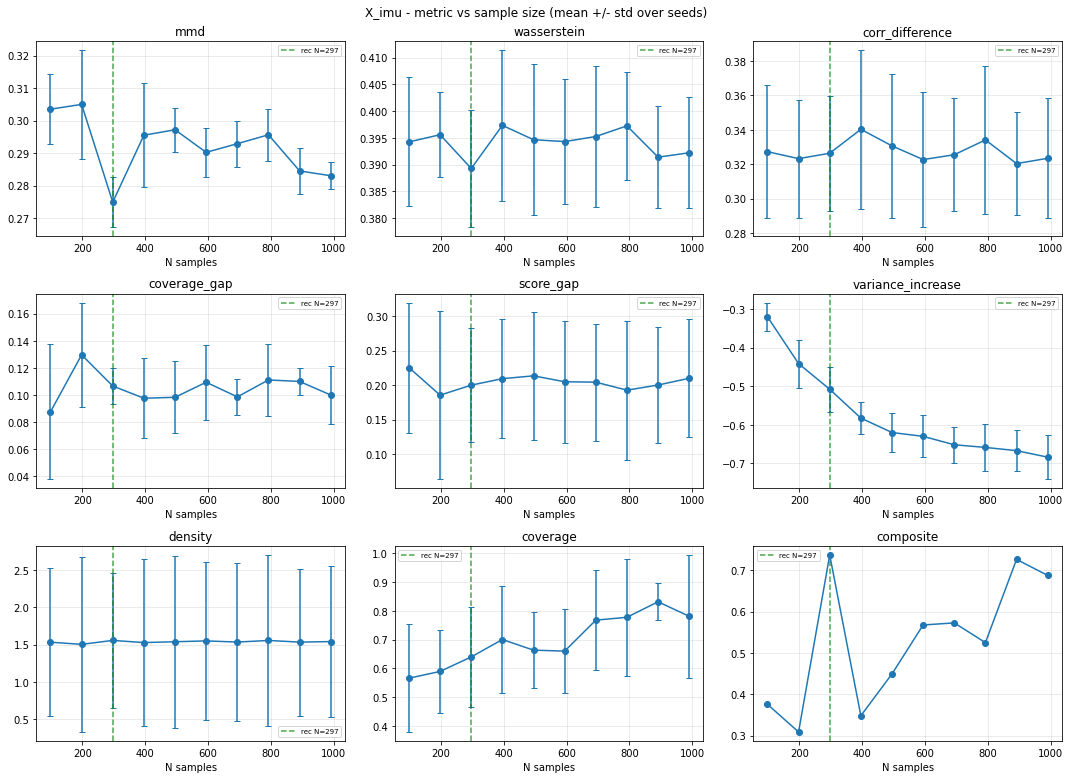

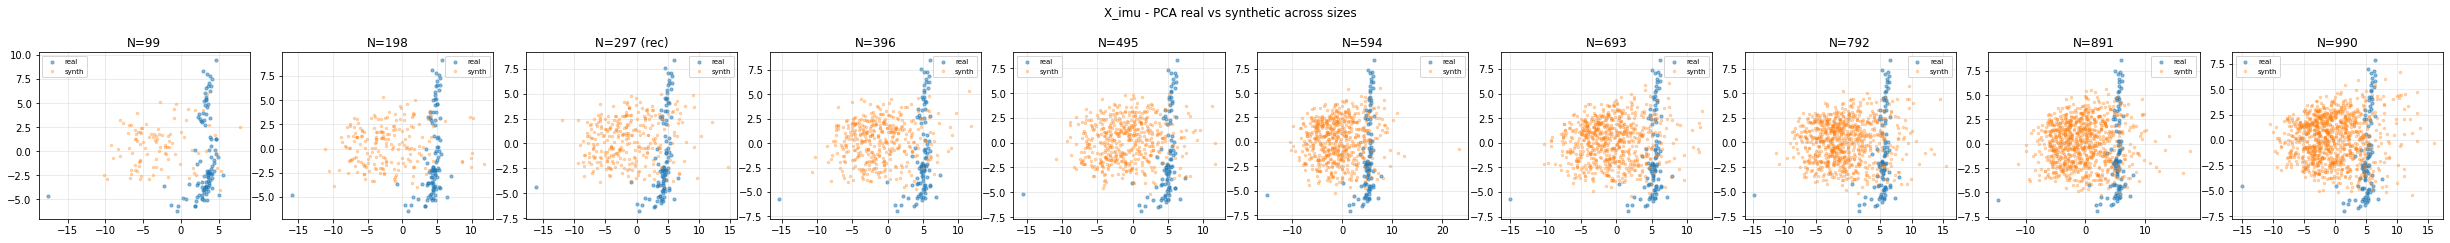

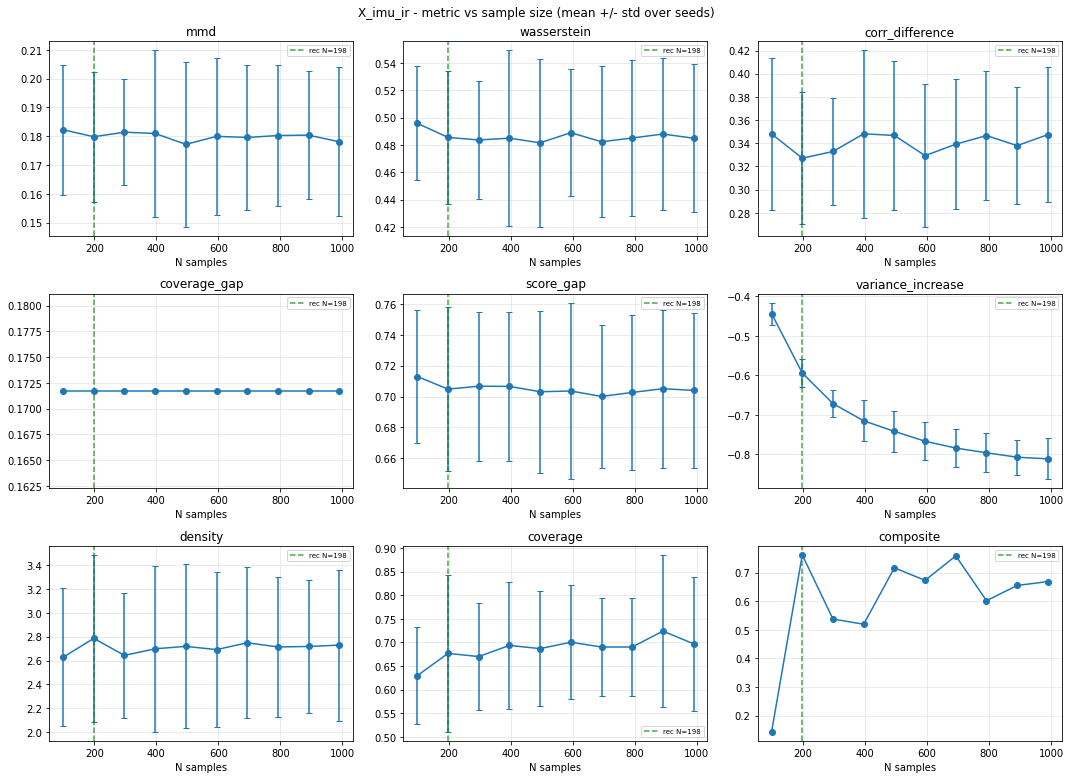

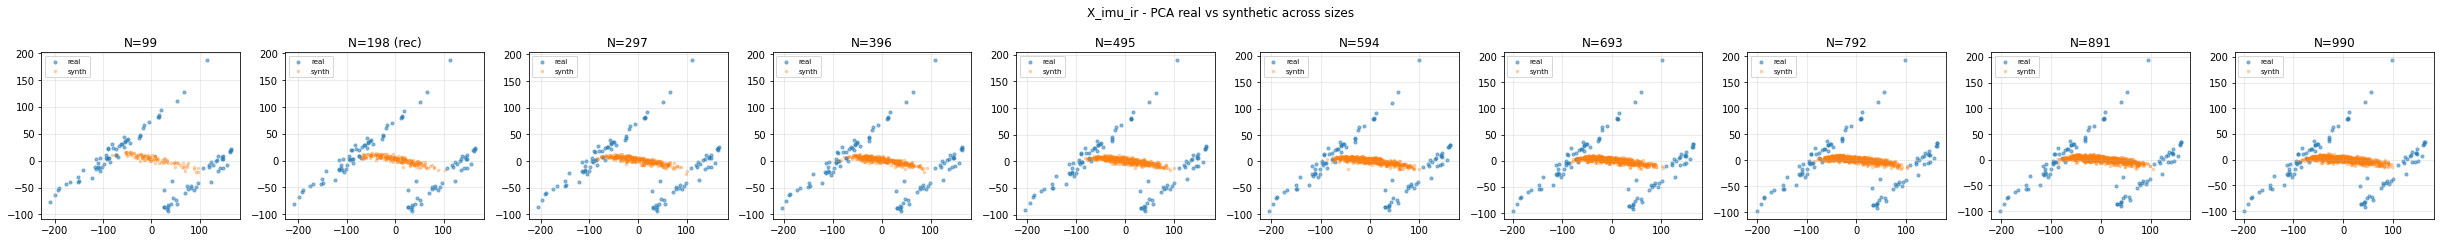

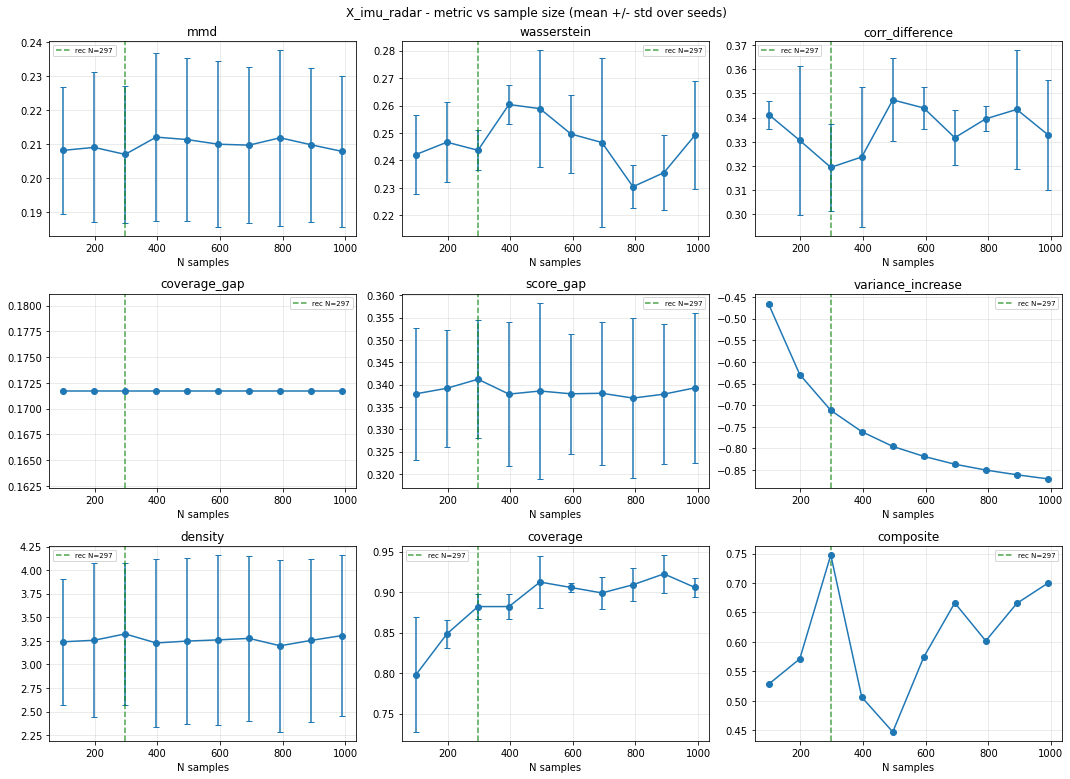

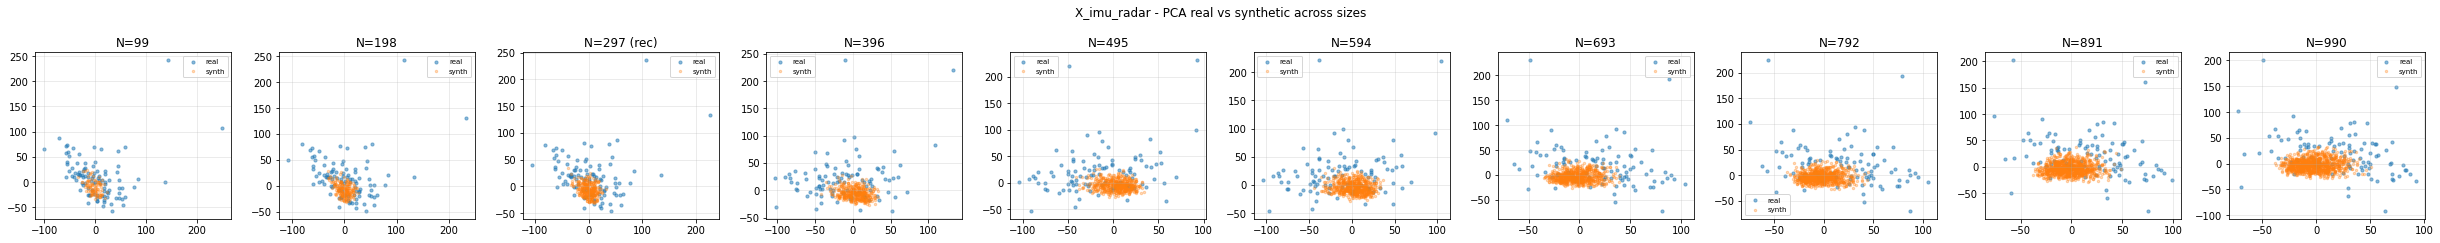

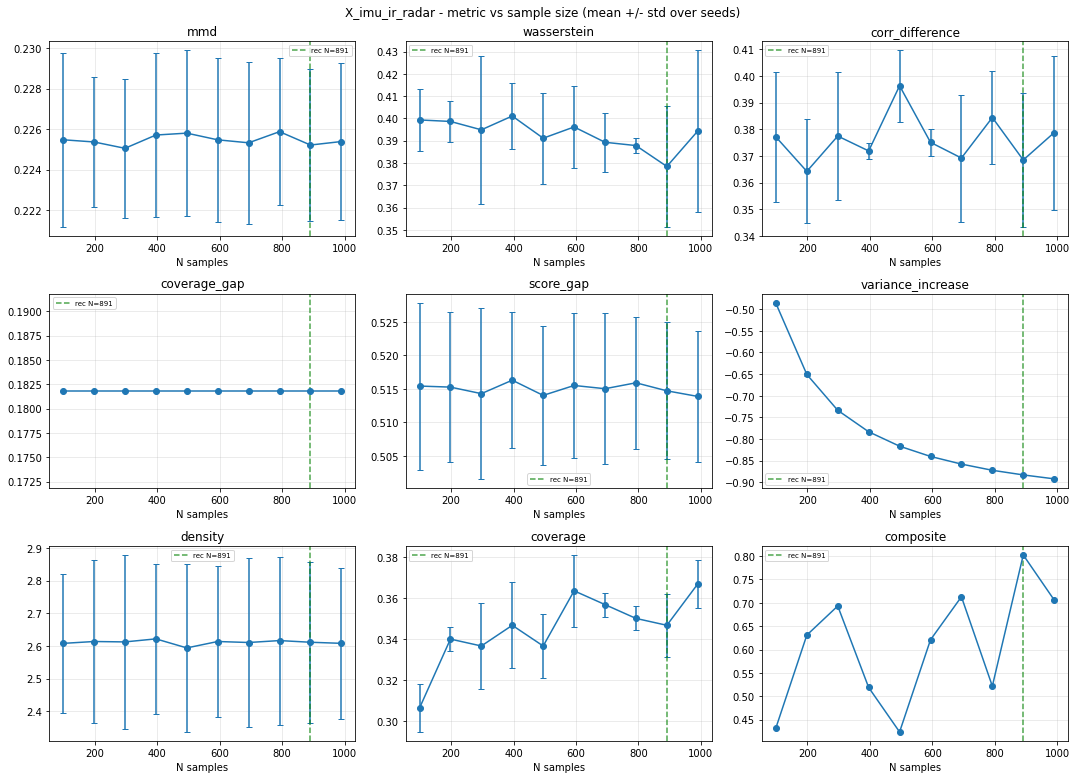

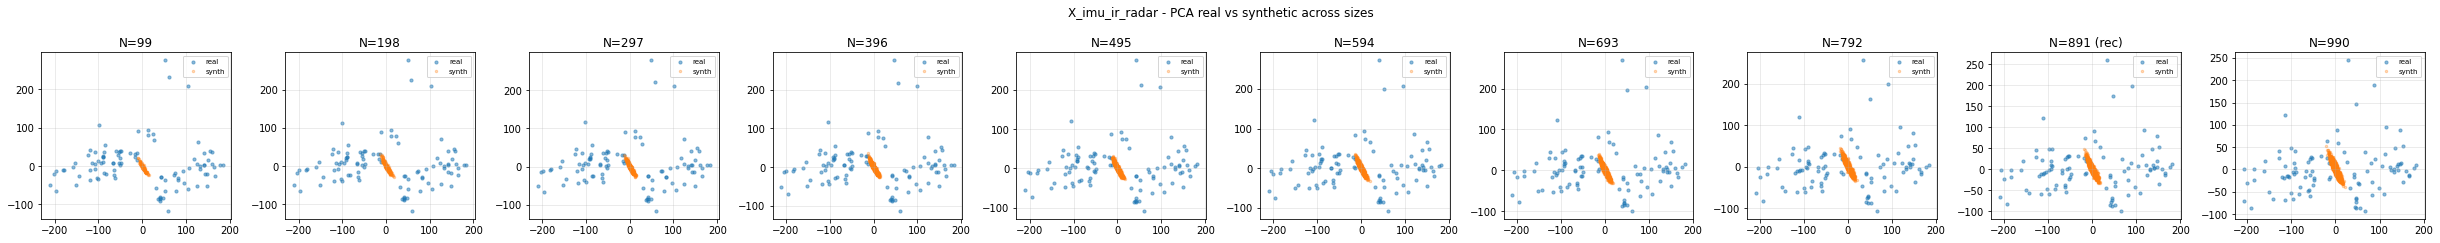

In [13]:
def plot_curves(name):
    sub=AGG[AGG.dataset==name].sort_values("N"); ss=AGG_STD[AGG_STD.dataset==name].sort_values("N")
    mets=["mmd","wasserstein","corr_difference","coverage_gap","score_gap","variance_increase","density","coverage","composite"]
    recN=REC[name]["N"]; fig,axes=plt.subplots(3,3,figsize=(15,11))
    for ax,mt in zip(axes.ravel(),mets):
        x=sub["N"].values; y=sub[mt].values
        yerr=ss[mt].values if mt in ss and mt!="composite" else None
        ax.errorbar(x,y,yerr=yerr,marker="o",capsize=3)
        ax.axvline(recN,color="green",ls="--",alpha=.7,label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} - metric vs sample size (mean +/- std over seeds)")
    fig.tight_layout(); fig.savefig(CFG.output_dir/f"{name}_curves.png",dpi=110); plt.show(); plt.close(fig)

def plot_pca(name):
    Re=EMB[name]["Re"]; syn=EMB[name]["synth"]; sizes=sorted(syn)
    fig,axes=plt.subplots(1,len(sizes),figsize=(3.4*len(sizes),3.4),squeeze=False)
    for j,N in enumerate(sizes):
        allp=np.vstack([Re,syn[N]]); p=PCA(2,random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T,s=10,alpha=.5,label="real")
        axes[0][j].scatter(*p[len(Re):].T,s=6,alpha=.3,label="synth")
        tag=" (rec)" if N==REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} - PCA real vs synthetic across sizes"); fig.tight_layout()
    fig.savefig(CFG.output_dir/f"{name}_pca.png",dpi=110); plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name)


## 13. Save synthetic data at the recommended size + package

In [14]:
import shutil
for name in RAW:
    vae,prep,latent,_=MODELS[name]; recN=REC[name]["N"]
    set_seeds(CFG.seed)
    synth=generate(vae,prep,recN,CFG,latent)
    d=CFG.output_dir/name; d.mkdir(parents=True,exist_ok=True)
    np.save(d/"synthetic_recommended.npy",synth)
    with open(d/"prep.pkl","wb") as f: pickle.dump(prep,f)
    vae.decoder.save(d/"decoder.keras")
    pd.DataFrame([{"dataset":name,"recommended_N":recN,"multiplier":REC[name]["multiplier"],
                   "n_features":prep.F_full,"modeled_dim":prep.K}]).to_csv(d/"metadata.csv",index=False)
    print(f"  {name:16s} saved {synth.shape} at recommended N={recN}")
arch=shutil.make_archive(str(CFG.output_dir),"zip",root_dir=str(CFG.output_dir))
print("\nZipped ->",arch)


  X_imu            saved (297, 32, 3) at recommended N=297
  X_imu_ir         saved (198, 32, 771) at recommended N=198
  X_imu_radar      saved (297, 32, 1137) at recommended N=297
  X_imu_ir_radar   saved (891, 32, 1905) at recommended N=891

Zipped -> /voc/work/exp_2/vae_size_study.zip


## Reading the results

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

Caveats: with ~99 real samples the VAE resamples a learned manifold, so a "recommended size" tells you how
much to draw before returns vanish, not how to exceed the data-scarcity ceiling. The knee is averaged over
`n_seeds` splits; raise `n_seeds` to 5 for a tighter estimate. The real reference here is the full real set
(consistent across sizes); the study measures **relative** saturation, not absolute fidelity.

## 14. Repeated-run stability analysis — robust final recommendation

Sections 9-13 produce one recommendation per dataset from a single full
**Generation -> Evaluation -> Recommendation** pass. To measure how stable that
recommendation is, we now repeat the **entire existing pipeline** `N_REPEATS`
times as independent runs, reusing `run_sweep`, `aggregate` and `recommend`
**unchanged** — the existing evaluation stays the sole authority for each run's
recommendation. Each run gets its own seed offset (`CFG.seed + rep*REP_SEED_STRIDE`),
so the runs are independent yet fully reproducible; run 0 keeps the original
`CFG.seed`, so it reproduces the single-pass result and acts as an anchor.

For every dataset we then collect the per-run recommended multiplier, take the
**mean** across runs, and snap that mean to the **nearest multiplier actually
generated in the sweep grid** (`CFG.multipliers`). That snapped multiplier is the
robust final representative recommendation. *Example:* runs recommending
`x4, x6, x8, x5, x6` give mean `5.8`, whose nearest available multiplier is `x6`.

The robust final dataset is regenerated at the selected multiplier from the same
kept VAE used in Section 13 (`MODELS[name]`, with `set_seeds(CFG.seed)`), so only
the *size* recommendation is made robust — the generator and methodology are
unchanged.

> **Compute note.** Every repetition retrains all `n_seeds` VAEs for all datasets,
> so wall-clock time scales roughly linearly with `N_REPEATS` (one repetition is a
> full VAE sweep). Lower `N_REPEATS` below if you want a faster pass.

All existing single-pass outputs are preserved untouched; the robust results are
written to new files (`*_repeated_final.npy`, `metadata_repeated.csv`,
`repeated_run_stability.csv`).

In [15]:
# --- Repeated-run stability configuration (change N_REPEATS to taste) ---
# NOTE: each repetition re-runs the full VAE sweep (train n_seeds models per dataset,
# then generate + evaluate at every size), so runtime grows ~linearly with N_REPEATS.

N_REPEATS = 5          # number of independent Generation -> Evaluation -> Recommendation runs
REP_SEED_STRIDE = 1000 # seed spacing between runs (keeps each run's seed block independent)

print(f"Repeated-run analysis: {N_REPEATS} independent runs "
      f"(seeds {CFG.seed} + rep*{REP_SEED_STRIDE}), reusing the existing pipeline unchanged.")

Repeated-run analysis: 5 independent runs (seeds 42 + rep*1000), reusing the existing pipeline unchanged.


In [16]:
from dataclasses import replace as _dc_replace

# One record per dataset: the recommendation + full evaluation trace from every repetition.
REPEAT_RESULTS = {name: {"seeds": [], "rec_multiplier": [], "rec_N": [],
                         "composite_at_rec": [], "composite_grid": [],
                         "grid_multipliers": None, "grid_N": None,
                         "metric_frames": []} for name in RAW}

for rep in range(N_REPEATS):
    rep_seed = CFG.seed + rep * REP_SEED_STRIDE     # run 0 == CFG.seed -> reproduces the single pass
    cfg_rep = _dc_replace(CFG, seed=rep_seed)       # identical config, independent seed
    set_seeds(rep_seed)                             # keep global RNG state reproducible per run

    # ----- existing pipeline, executed exactly as-is (models are retrained internally) -----
    results_rep, _emb_rep, _models_rep = run_sweep(cfg_rep)      # Generation + Evaluation
    agg_rep, _agg_std_rep = aggregate(results_rep)              # Aggregate over seeds

    for name in RAW:
        sub = agg_rep[agg_rep.dataset == name].sort_values("N").reset_index(drop=True)
        C, recN, recM = recommend(sub, cfg_rep)                # Recommendation (unchanged authority)
        store = REPEAT_RESULTS[name]
        store["seeds"].append(rep_seed)
        store["rec_multiplier"].append(int(recM))
        store["rec_N"].append(int(recN))
        store["composite_at_rec"].append(float(C[sub["N"].values == recN][0]))
        store["composite_grid"].append(np.asarray(C, float))
        sub_c = sub.copy(); sub_c["composite"] = C; sub_c["rep"] = rep
        store["metric_frames"].append(sub_c)
        if store["grid_multipliers"] is None:
            store["grid_multipliers"] = sub["multiplier"].values.astype(int)
            store["grid_N"] = sub["N"].values.astype(int)

    del _emb_rep, _models_rep     # only recommendations/metrics are needed downstream; free memory

    print(f"  rep {rep + 1:>2}/{N_REPEATS} (seed {rep_seed}): "
          + ", ".join(f"{name}->{REPEAT_RESULTS[name]['rec_multiplier'][-1]}x" for name in RAW))

set_seeds(CFG.seed)   # restore the original global seed after the repeated runs
print(f"\nrepeated runs done: {N_REPEATS} x full pipeline over {len(RAW)} datasets")


=== X_imu ((99, 32, 3)) ===
  seed 42: trained 250 ep in 25s (K=3, dropped 0)
  seed 43: trained 132 ep in 17s (K=3, dropped 0)
  seed 44: trained 168 ep in 19s (K=3, dropped 0)

=== X_imu_ir ((99, 32, 771)) ===
  seed 42: trained 174 ep in 20s (K=32, dropped 0)
  seed 43: trained 218 ep in 23s (K=32, dropped 0)
  seed 44: trained 250 ep in 26s (K=32, dropped 0)

=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 139 ep in 17s (K=32, dropped 294)
  seed 43: trained 53 ep in 11s (K=32, dropped 294)
  seed 44: trained 165 ep in 19s (K=32, dropped 294)

=== X_imu_ir_radar ((99, 32, 1905)) ===
  seed 42: trained 108 ep in 15s (K=32, dropped 294)
  seed 43: trained 53 ep in 11s (K=32, dropped 294)
  seed 44: trained 124 ep in 16s (K=32, dropped 294)
  rep  1/5 (seed 42): X_imu->2x, X_imu_ir->7x, X_imu_radar->3x, X_imu_ir_radar->7x

=== X_imu ((99, 32, 3)) ===
  seed 1042: trained 250 ep in 26s (K=3, dropped 0)
  seed 1043: trained 227 ep in 24s (K=3, dropped 0)
  seed 1044: trained 21

In [17]:
def _nearest_grid_multiplier(mean_val, grid):
    # nearest multiplier that was actually generated; ties resolve to the smaller (conservative) one
    grid = np.asarray(sorted(set(int(g) for g in grid)))
    return int(grid[int(np.argmin(np.abs(grid - float(mean_val))))])

REPEAT_SUMMARY_ROWS = []
REPEAT_FINAL = {}   # name -> robust final selection

for name in RAW:
    store = REPEAT_RESULTS[name]
    recs = np.asarray(store["rec_multiplier"], float)
    grid_mults = store["grid_multipliers"]; grid_N = store["grid_N"]

    mean_rec = float(recs.mean())                                  # mean recommendation across runs
    sel_mult = _nearest_grid_multiplier(mean_rec, grid_mults)      # snap to nearest generated multiplier
    sel_N = int(grid_N[list(grid_mults).index(sel_mult)])

    # mean composite (existing evaluation score) across runs at the selected multiplier
    comp_grid = np.vstack(store["composite_grid"])                 # (N_REPEATS, n_grid)
    gi = int(list(grid_mults).index(sel_mult))
    mean_comp_at_sel = float(comp_grid[:, gi].mean())

    # mean of the raw evaluation metrics across runs at the selected multiplier
    frames = pd.concat(store["metric_frames"], ignore_index=True)
    sel_metrics = frames[frames["multiplier"] == sel_mult].mean(numeric_only=True)

    REPEAT_FINAL[name] = {
        "mean_multiplier": mean_rec, "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": mean_comp_at_sel,
        "per_rep_multipliers": [int(m) for m in store["rec_multiplier"]],
        "single_pass_multiplier": int(REC[name]["multiplier"]), "single_pass_N": int(REC[name]["N"]),
    }
    REPEAT_SUMMARY_ROWS.append({
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in store["rec_multiplier"]),
        "mean_multiplier": round(mean_rec, 3), "selected_multiplier": f"{sel_mult}x",
        "selected_N": sel_N, "single_pass_multiplier": f"{REC[name]['multiplier']}x",
        "mean_composite_at_selected": round(mean_comp_at_sel, 4),
        "mmd": float(sel_metrics.get("mmd", np.nan)),
        "wasserstein": float(sel_metrics.get("wasserstein", np.nan)),
        "coverage": float(sel_metrics.get("coverage", np.nan)),
    })

REPEAT_SUMMARY = pd.DataFrame(REPEAT_SUMMARY_ROWS).set_index("dataset")
REPEAT_SUMMARY.to_csv(CFG.output_dir / "repeated_run_stability.csv")

# persist every per-run evaluation table too (all relevant evaluation results)
per_rep_all = pd.concat([f for name in RAW for f in REPEAT_RESULTS[name]["metric_frames"]],
                        ignore_index=True)
per_rep_all.to_csv(CFG.output_dir / "repeated_run_per_rep_metrics.csv", index=False)

print("################ REPEATED-RUN STABILITY SUMMARY ################")
display(REPEAT_SUMMARY)

################ REPEATED-RUN STABILITY SUMMARY ################


,n_repeats,per_rep_multipliers,mean_multiplier,selected_multiplier,selected_N,single_pass_multiplier,mean_composite_at_selected,mmd,wasserstein,coverage
dataset,,,,,,,,,,
X_imu,5,2x 2x 4x 5x 9x,4.4000,4x,396,3x,0.4673,0.4214,0.4285,0.5798
X_imu_ir,5,7x 1x 2x 9x 6x,5.0000,5x,495,2x,0.4555,0.2132,0.5493,0.5165
X_imu_radar,5,3x 2x 3x 4x 7x,3.8000,4x,396,3x,0.5296,0.2519,0.2597,0.7744
X_imu_ir_radar,5,7x 7x 2x 8x 1x,5.0000,5x,495,9x,0.5467,0.2411,0.4039,0.3219


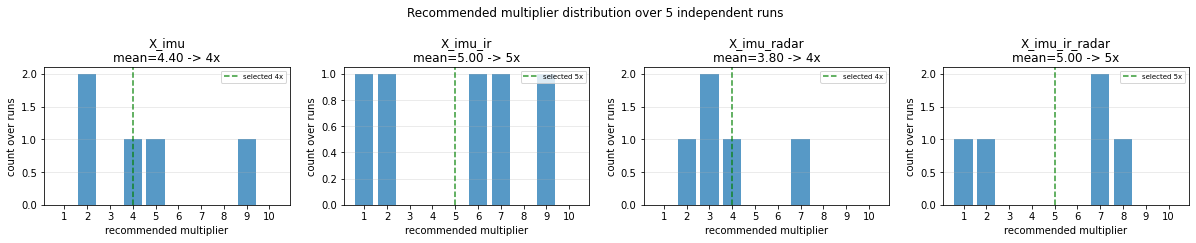

In [18]:
# distribution of the recommended multiplier over the independent runs (per dataset)
grid_all = sorted(set(int(m) for m in CFG.multipliers))
fig, axes = plt.subplots(1, len(RAW), figsize=(4.2 * len(RAW), 3.4), squeeze=False)
for ax, name in zip(axes[0], RAW):
    recs = REPEAT_RESULTS[name]["rec_multiplier"]
    counts = [recs.count(m) for m in grid_all]
    ax.bar([str(m) for m in grid_all], counts, alpha=.75)
    sel = REPEAT_FINAL[name]["selected_multiplier"]; mean_rec = REPEAT_FINAL[name]["mean_multiplier"]
    ax.axvline(grid_all.index(sel), color="green", ls="--", alpha=.8, label=f"selected {sel}x")
    ax.set_title(f"{name}\nmean={mean_rec:.2f} -> {sel}x")
    ax.set_xlabel("recommended multiplier"); ax.set_ylabel("count over runs")
    ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=7)
fig.suptitle(f"Recommended multiplier distribution over {N_REPEATS} independent runs")
fig.tight_layout(); fig.savefig(CFG.output_dir / "repeated_run_stability.png", dpi=110)
plt.show(); plt.close(fig)

In [19]:
# Regenerate + save the robust final dataset at the selected multiplier, then report.
# Uses the same kept VAE as Section 13 (MODELS[name]) so only the *size* is made robust;
# writes NEW filenames only -- the existing single-pass outputs are left untouched.
print("################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################\n")
for name in RAW:
    fin = REPEAT_FINAL[name]
    sel_N = fin["selected_N"]; sel_mult = fin["selected_multiplier"]

    vae, prep, latent, _ = MODELS[name]          # canonical kept model (same generator as Section 13)
    set_seeds(CFG.seed)                          # reproducible generation, matching Section 13
    synth = generate(vae, prep, sel_N, CFG, latent)

    d = CFG.output_dir / name; d.mkdir(parents=True, exist_ok=True)
    final_path = d / "synthetic_repeated_final.npy"
    np.save(final_path, synth)
    pd.DataFrame([{
        "dataset": name, "n_repeats": N_REPEATS,
        "per_rep_multipliers": " ".join(f"{m}x" for m in fin["per_rep_multipliers"]),
        "mean_multiplier": fin["mean_multiplier"],
        "selected_multiplier": sel_mult, "selected_N": sel_N,
        "mean_composite_at_selected": fin["mean_composite_at_selected"],
        "single_pass_multiplier": fin["single_pass_multiplier"],
        "single_pass_N": fin["single_pass_N"],
        "n_features": prep.F_full, "modeled_dim": prep.K,
    }]).to_csv(d / "metadata_repeated.csv", index=False)

    print(f"=== {name} ===")
    print(f"  per-run recommendations : {' '.join(f'{m}x' for m in fin['per_rep_multipliers'])}")
    print(f"  mean recommendation     : {fin['mean_multiplier']:.3f}x")
    print(f"  selected robust final   : {sel_mult}x  (N={sel_N})")
    print(f"  single-pass baseline    : {fin['single_pass_multiplier']}x (N={fin['single_pass_N']})")
    print(f"  mean composite @ final  : {fin['mean_composite_at_selected']:.4f}")
    print(f"  final dataset saved     : {tuple(synth.shape)} -> {final_path}\n")

print("Existing single-pass outputs preserved. Robust final outputs written as")
print("  <dataset>/synthetic_repeated_final.npy, <dataset>/metadata_repeated.csv,")
print("  repeated_run_stability.csv, repeated_run_per_rep_metrics.csv, repeated_run_stability.png")
print("(The generator is the Section 13 kept VAE, whose decoder.keras / prep.pkl already exist.)")

################ FINAL REPRESENTATIVE RECOMMENDATION (repeated-run) ################

=== X_imu ===
  per-run recommendations : 2x 2x 4x 5x 9x
  mean recommendation     : 4.400x
  selected robust final   : 4x  (N=396)
  single-pass baseline    : 3x (N=297)
  mean composite @ final  : 0.4673
  final dataset saved     : (396, 32, 3) -> /voc/work/exp_2/vae_size_study/X_imu/synthetic_repeated_final.npy

=== X_imu_ir ===
  per-run recommendations : 7x 1x 2x 9x 6x
  mean recommendation     : 5.000x
  selected robust final   : 5x  (N=495)
  single-pass baseline    : 2x (N=198)
  mean composite @ final  : 0.4555
  final dataset saved     : (495, 32, 771) -> /voc/work/exp_2/vae_size_study/X_imu_ir/synthetic_repeated_final.npy

=== X_imu_radar ===
  per-run recommendations : 3x 2x 3x 4x 7x
  mean recommendation     : 3.800x
  selected robust final   : 4x  (N=396)
  single-pass baseline    : 3x (N=297)
  mean composite @ final  : 0.5296
  final dataset saved     : (396, 32, 1137) -> /voc/work/exp